In [1]:
import os

print("Checking for the dataset...")

# This searches the background folder to prove the data is already there
found_file = False
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        if file.endswith('.h5'):
            print(f"✅ SUCCESS! Dataset found at: {os.path.join(root, file)}")
            found_file = True
            break

if not found_file:
    print("❌ Dataset not found.")

Checking for the dataset...
✅ SUCCESS! Dataset found at: /kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset/Cyclone_Images.h5


HDF5 Keys: ['Images']
Dataset Shape: (21076, 128, 128, 4)
Label files found: ['Cyclone_Labels h5.npy']


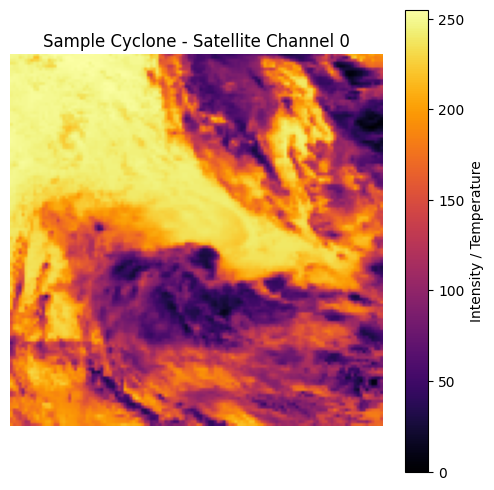

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_DIR = '/kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset'
IMAGES_PATH = os.path.join(DATA_DIR, 'Cyclone_Images.h5')

# Open and inspect the HDF5 container
with h5py.File(IMAGES_PATH, 'r') as h5_file:
    print("HDF5 Keys:", list(h5_file.keys()))
    
    # TCIR datasets store arrays under 'matrix' or similar primary key
    key = list(h5_file.keys())[0]
    data = h5_file[key]
    print(f"Dataset Shape: {data.shape}")
    
    # Extract the first image (Infrared channel)
    sample_img = data[0, :, :, 0] if len(data.shape) == 4 else data[0]
    sample_img = np.nan_to_num(sample_img, nan=0.0)

# Check for label file
labels_file = [f for f in os.listdir(DATA_DIR) if f.endswith(('.npy', '.csv'))]
print("Label files found:", labels_file)

# Plot the sample cyclone
plt.figure(figsize=(6, 6))
plt.imshow(sample_img, cmap='inferno')
plt.title("Sample Cyclone - Satellite Channel 0")
plt.colorbar(label="Intensity / Temperature")
plt.axis('off')
plt.show()

In [3]:
import os
import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
import torchvision.transforms as transforms
import torch.optim as optim

# 1. Define paths
DATA_DIR = '/kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset'
IMAGES_PATH = os.path.join(DATA_DIR, 'Cyclone_Images.h5')
LABELS_PATH = os.path.join(DATA_DIR, 'Cyclone_Labels h5.npy')

# 2. PyTorch Dataset tailored to extract only the wind speed column
class CycloneDataset(Dataset):
    def __init__(self, h5_path, labels_path):
        self.h5_file = h5py.File(h5_path, 'r')
        self.images = self.h5_file['Images']
        
        # Load the raw table (which contains strings like 'ATLN' and numbers)
        raw_labels = np.load(labels_path, allow_pickle=True)
        
        # Print the first row so we can see the exact structure in your output
        print("Dataset metadata sample (first row):", raw_labels[0])
        
        # Extract ONLY the wind speed column (typically index 5 in TCIR datasets)
        # and convert just those numbers to float32 for PyTorch
        try:
            self.labels = raw_labels[:, 5].astype(np.float32)
        except ValueError:
            print("Error: Column 5 contains text. Check the 'metadata sample' above to find the correct wind speed index.")
            self.labels = np.zeros(len(raw_labels)) # Fallback to prevent immediate crash
        
        self.resize = transforms.Resize((224, 224), antialias=True)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Extract IR channel (Channel 0)
        img = self.images[idx, :, :, 0]
        
        # Clean NaNs and min-max normalize [0, 1]
        img = np.nan_to_num(img, nan=0.0)
        min_val, max_val = np.min(img), np.max(img)
        img = (img - min_val) / (max_val - min_val + 1e-8)
        
        # Convert to 3-channel Tensor for ResNet
        img_tensor = torch.tensor(img, dtype=torch.float32).unsqueeze(0).repeat(3, 1, 1)
        img_tensor = self.resize(img_tensor)
        
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img_tensor, label

# 3. Create Dataset and 80/20 Train-Val Split
full_dataset = CycloneDataset(IMAGES_PATH, LABELS_PATH)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_set, val_set = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_set, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, num_workers=2)

print(f"Dataset ready: {train_size} training samples, {val_size} validation samples.")

# 4. Model Architecture: ResNet50 for Wind Speed Regression
class CycloneIntensityModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
        
        # Freeze early layers
        for param in list(self.resnet.parameters())[:-15]:
            param.requires_grad = False
            
        # Custom regression head (Wind Speed in knots)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.resnet(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CycloneIntensityModel().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0003)

print(f"Training on device: {device}")

# 5. Training Loop
EPOCHS = 5

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images).squeeze(-1)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{EPOCHS}], Batch [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}")
            
    epoch_loss = running_loss / len(train_loader)
    print(f"=== Epoch {epoch+1}/{EPOCHS} Finished | Train MSE Loss: {epoch_loss:.4f} ===")

# 6. Save Weights to /kaggle/working/
SAVE_PATH = '/kaggle/working/cyclone_resnet_weights.pth'
torch.save(model.cpu().state_dict(), SAVE_PATH)
print(f"Model saved successfully to: {SAVE_PATH}")

Dataset metadata sample (first row): ['ATLN' '200301L' -66.0 31.4 '2003041815' 30.0 0.0 1008.0]
Dataset ready: 16860 training samples, 4216 validation samples.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 192MB/s]


Training on device: cuda
Epoch [1/5], Batch [100/527], Loss: 369.7182
Epoch [1/5], Batch [200/527], Loss: 164.1408
Epoch [1/5], Batch [300/527], Loss: 160.5680
Epoch [1/5], Batch [400/527], Loss: 234.7710
Epoch [1/5], Batch [500/527], Loss: 603.8704
=== Epoch 1/5 Finished | Train MSE Loss: 407.0472 ===
Epoch [2/5], Batch [100/527], Loss: 206.4449
Epoch [2/5], Batch [200/527], Loss: 106.7413
Epoch [2/5], Batch [300/527], Loss: 126.2917
Epoch [2/5], Batch [400/527], Loss: 104.7165
Epoch [2/5], Batch [500/527], Loss: 239.2916
=== Epoch 2/5 Finished | Train MSE Loss: 138.6270 ===
Epoch [3/5], Batch [100/527], Loss: 114.1306
Epoch [3/5], Batch [200/527], Loss: 124.4495
Epoch [3/5], Batch [300/527], Loss: 109.1738
Epoch [3/5], Batch [400/527], Loss: 86.6483
Epoch [3/5], Batch [500/527], Loss: 51.9446
=== Epoch 3/5 Finished | Train MSE Loss: 91.5480 ===
Epoch [4/5], Batch [100/527], Loss: 66.6163
Epoch [4/5], Batch [200/527], Loss: 91.7063
Epoch [4/5], Batch [300/527], Loss: 60.3075
Epoch [4/

Running inference on the validation set...
Validation MAE: 6.08 knots
Validation RMSE: 24.72 knots


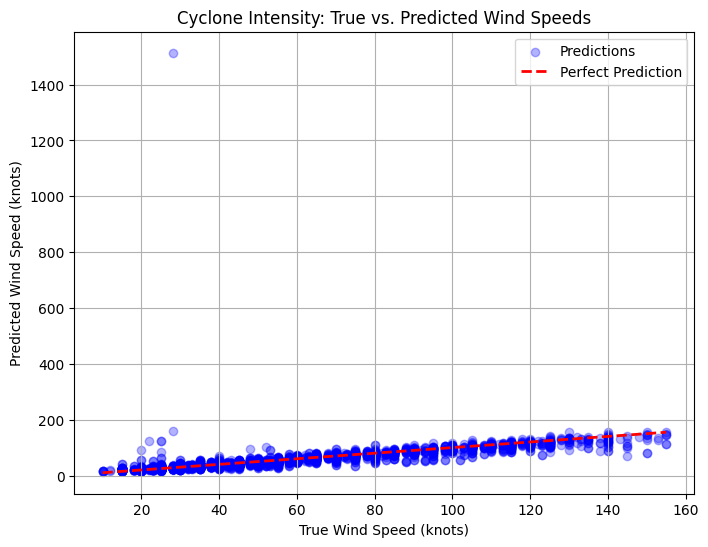

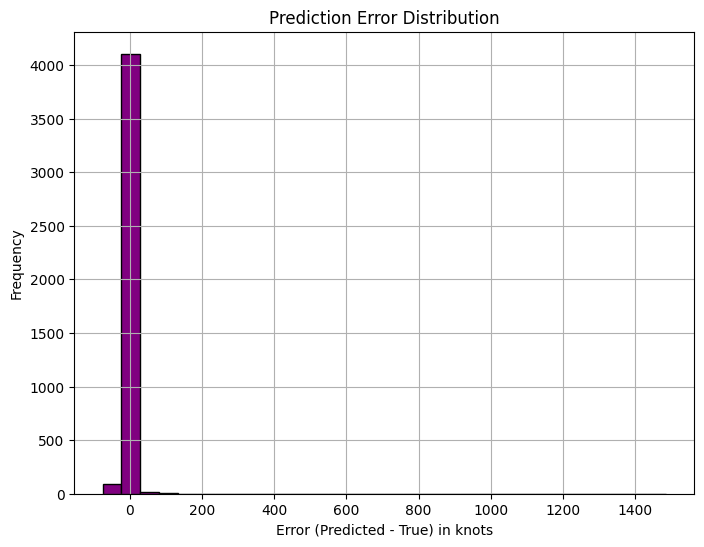

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Move model back to GPU and set to evaluation mode
model = model.to(device)
model.eval()

all_preds = []
all_targets = []

print("Running inference on the validation set...")

# 2. Iterate through validation data without calculating gradients
with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        
        # Get predictions
        outputs = model(images).squeeze(-1).cpu().numpy()
        targets = labels.cpu().numpy()
        
        all_preds.extend(outputs)
        all_targets.extend(targets)

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# 3. Calculate Standard Meteorological Testing Parameters
mae = mean_absolute_error(all_targets, all_preds)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))

print(f"Validation MAE: {mae:.2f} knots")
print(f"Validation RMSE: {rmse:.2f} knots")

# 4. Plot True vs Predicted Wind Speeds
plt.figure(figsize=(8, 6))
plt.scatter(all_targets, all_preds, alpha=0.3, color='blue', label='Predictions')
plt.plot([min(all_targets), max(all_targets)], 
         [min(all_targets), max(all_targets)], 
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title("Cyclone Intensity: True vs. Predicted Wind Speeds")
plt.xlabel("True Wind Speed (knots)")
plt.ylabel("Predicted Wind Speed (knots)")
plt.legend()
plt.grid(True)
plt.show()

# 5. Plot Error Distribution (Residuals)
errors = all_preds - all_targets
plt.figure(figsize=(8, 6))
plt.hist(errors, bins=30, color='purple', edgecolor='black')
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Predicted - True) in knots")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

Overall Model R² Score: 0.3304 (1.0 is perfect)

--- Mean Absolute Error (MAE) by Storm Category ---
Depression (<34 kts)        : 4.72 kts error | Samples: 1503
Cyclonic Storm (34-63 kts)  : 5.36 kts error | Samples: 1560
Severe Storm (64-89 kts)    : 7.07 kts error | Samples: 539
Extreme/Super (90+ kts)     : 10.35 kts error | Samples: 614

Generating edge-case visualization...


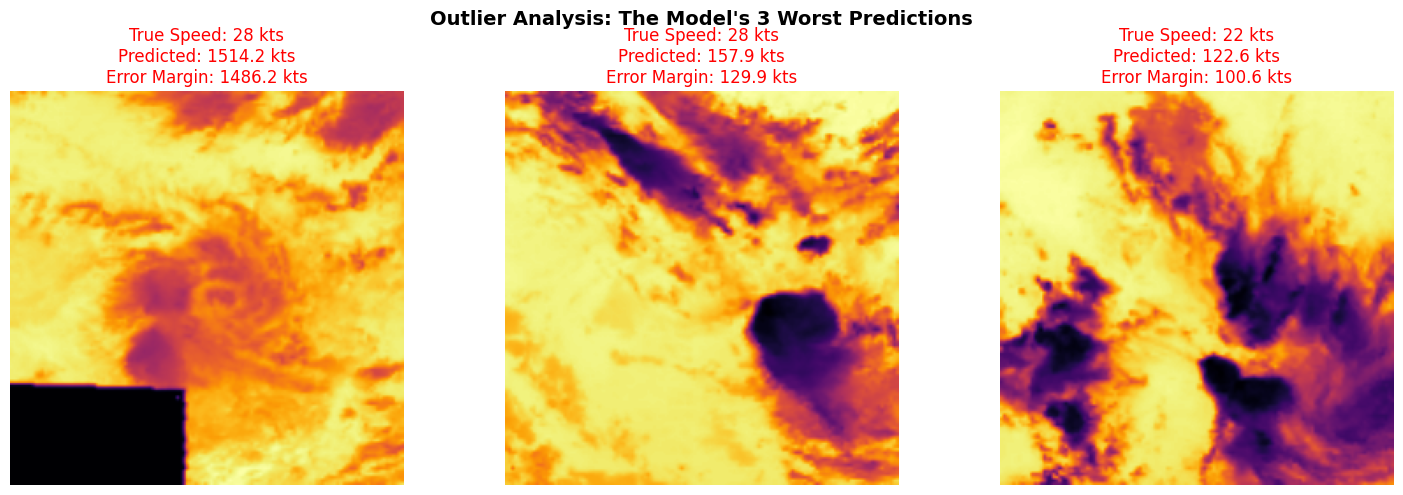

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# 1. R-Squared Calculation (Measures how well the model explains the variance)
r2 = r2_score(all_targets, all_preds)
print(f"Overall Model R² Score: {r2:.4f} (1.0 is perfect)")

# 2. Stratified Error Analysis (Binned by Intensity)
print("\n--- Mean Absolute Error (MAE) by Storm Category ---")
bins = [0, 34, 64, 90, 200]
category_labels = [
    "Depression (<34 kts)", 
    "Cyclonic Storm (34-63 kts)", 
    "Severe Storm (64-89 kts)", 
    "Extreme/Super (90+ kts)"
]

for i in range(4):
    mask = (all_targets >= bins[i]) & (all_targets < bins[i+1])
    if np.sum(mask) > 0:
        bin_mae = np.mean(np.abs(all_targets[mask] - all_preds[mask]))
        count = np.sum(mask)
        print(f"{category_labels[i]:<28}: {bin_mae:.2f} kts error | Samples: {count}")

# 3. Outlier Analysis (Visualizing the Model's Worst Failures)
errors = np.abs(all_targets - all_preds)
worst_idx = np.argsort(errors)[-3:]  # Grab the indices of the 3 largest errors

print("\nGenerating edge-case visualization...")
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Outlier Analysis: The Model's 3 Worst Predictions", fontsize=14, fontweight='bold')

for i, idx in enumerate(reversed(worst_idx)):
    # Fetch the exact raw image and label from the PyTorch Validation Dataset
    img_tensor, true_label = val_set[idx]
    
    # Extract just the first channel (IR) for display
    img_display = img_tensor[0].cpu().numpy()
    
    ax = axes[i]
    ax.imshow(img_display, cmap='inferno')
    ax.set_title(f"True Speed: {true_label.item():.0f} kts\nPredicted: {all_preds[idx]:.1f} kts\nError Margin: {errors[idx]:.1f} kts", color='red')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# The default hidden directory where Kaggle mounts dataset files
input_dir = '/kaggle/input'

# 1. Map the Directory Structure
print("--- DATASET FOLDER STRUCTURE ---")
image_files = []
csv_files = []
nc_h5_files = []

for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        filepath = os.path.join(dirname, filename)
        if filename.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            image_files.append(filepath)
        elif filename.lower().endswith('.csv'):
            csv_files.append(filepath)
        elif filename.lower().endswith(('.h5', '.nc', '.hdf5')):
            nc_h5_files.append(filepath)

print(f"Found {len(csv_files)} CSVs, {len(image_files)} Images, and {len(nc_h5_files)} HDF5/NetCDF files.\n")

# 2. Visualize Tabular Data (CSV Tracks / Labels)
if csv_files:
    print("--- PREVIEWING TABULAR DATA ---")
    for csv_file in csv_files[:2]: # Previews the first 2 CSVs found
        print(f"File: {os.path.basename(csv_file)}")
        try:
            df = pd.read_csv(csv_file)
            display(df.head())
            print(f"Shape: {df.shape}\n")
        except Exception as e:
            print(f"Could not read {csv_file}: {e}\n")

# 3. Visualize Image Data (JPG, PNG)
if image_files:
    print("--- PREVIEWING SATELLITE IMAGERY ---")
    num_plots = min(4, len(image_files))
    fig, axes = plt.subplots(1, num_plots, figsize=(16, 4))
    
    if num_plots == 1: axes = [axes]
        
    for i, img_path in enumerate(image_files[:num_plots]):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(os.path.basename(img_path)[:20])
            axes[i].axis('off')
        except Exception as e:
            axes[i].set_title("Error loading image")
            axes[i].axis('off')
            
    plt.tight_layout()
    plt.show()

# 4. Handle Meteorological Arrays (NetCDF / HDF5)
if nc_h5_files:
    print("--- METEOROLOGICAL ARRAYS DETECTED ---")
    print("Dataset contains raw scientific tensors. Use 'xarray' or 'h5py' to extract specific channels:")
    for file in nc_h5_files[:3]:
        print(f"- {file}")


--- DATASET FOLDER STRUCTURE ---
Found 0 CSVs, 0 Images, and 1 HDF5/NetCDF files.

--- METEOROLOGICAL ARRAYS DETECTED ---
Dataset contains raw scientific tensors. Use 'xarray' or 'h5py' to extract specific channels:
- /kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset/Cyclone_Images.h5


Loading and inspecting HDF5 file: /kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset/Cyclone_Images.h5

--- HDF5 DATASET STRUCTURE ---
Dataset: Images | Shape: (21076, 128, 128, 4) | Type: float32

--- VISUALIZING FIRST 3 CYCLONE SAMPLES FROM 'Images' ---


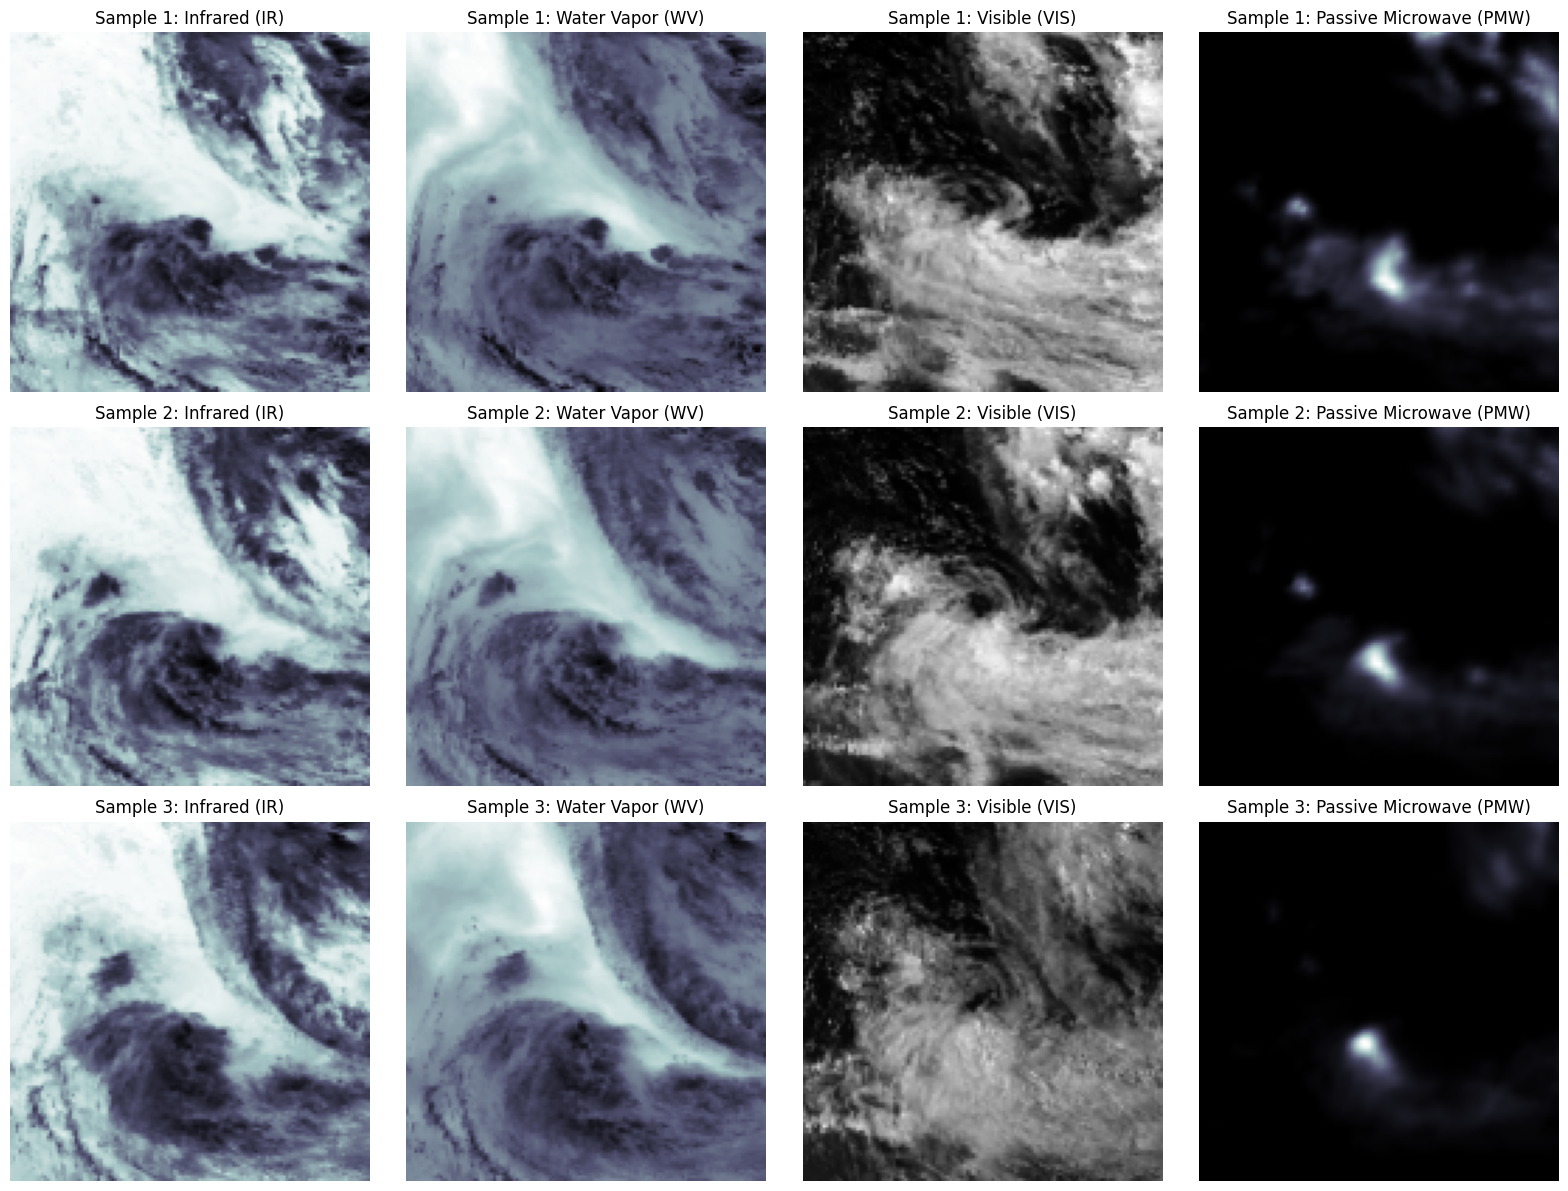

In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import os

# Target the specific HDF5 file identified in your Kaggle output
file_path = '/kaggle/input/datasets/vaukaofworlds/thecycloneimagedataset/Cyclone_Images.h5'

def print_h5_structure(name, obj):
    """Callback function to print the hierarchy and structure of the HDF5 file."""
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name} | Shape: {obj.shape} | Type: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"Group: {name}")

print(f"Loading and inspecting HDF5 file: {file_path}")

try:
    with h5py.File(file_path, 'r') as f:
        print("\n--- HDF5 DATASET STRUCTURE ---")
        # This will list all internal keys (like the image arrays and the label metadata)
        f.visititems(print_h5_structure)
        
        # Identify the dataset containing the image tensors
        img_dataset_name = None
        for name in f:
            if isinstance(f[name], h5py.Dataset) and len(f[name].shape) >= 3:
                img_dataset_name = name
                break
        
        if img_dataset_name:
            print(f"\n--- VISUALIZING FIRST 3 CYCLONE SAMPLES FROM '{img_dataset_name}' ---")
            data = f[img_dataset_name]
            
            channel_names = ['Infrared (IR)', 'Water Vapor (WV)', 'Visible (VIS)', 'Passive Microwave (PMW)']
            num_samples_to_show = min(3, data.shape[0])
            
            fig, axes = plt.subplots(num_samples_to_show, 4, figsize=(16, 4 * num_samples_to_show))
            if num_samples_to_show == 1:
                axes = np.expand_dims(axes, axis=0)
                
            for i in range(num_samples_to_show):
                sample = data[i]
                
                # Convert (C, H, W) to (H, W, C) if the channels are the first dimension
                if sample.shape[0] == 4 or sample.shape[0] == 3:
                    sample = np.transpose(sample, (1, 2, 0)) 
                
                for c in range(min(4, sample.shape[-1])):
                    ax = axes[i, c]
                    # Display the Visible channel in standard grayscale, others in specialized 'bone' map
                    cmap_choice = 'gray' if c == 2 else 'bone'
                    
                    ax.imshow(sample[..., c], cmap=cmap_choice)
                    ax.set_title(f"Sample {i+1}: {channel_names[c] if c < 4 else f'Channel {c+1}'}")
                    ax.axis('off')
            
            plt.tight_layout()
            plt.show()
        else:
            print("\nCould not automatically locate the image tensor array in the root directory.")
            
except Exception as e:
    print(f"Error executing HDF5 extraction: {e}")
